# 02 — Calidad de datos (SCRUM-9)

Visualización de nulos, estadísticas y atípicos por región.

**Jira:** SCRUM-9 · Genera `reporte_calidad_scrum9.json`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from gympulse.config import DEFAULT_CSV, QUALITY_REPORT
from gympulse.constants import METRICS
from gympulse.quality import build_quality_report, save_quality_report

sns.set_theme(style="whitegrid")
df = pd.read_csv(DEFAULT_CSV)

## Nulos globales y por columna

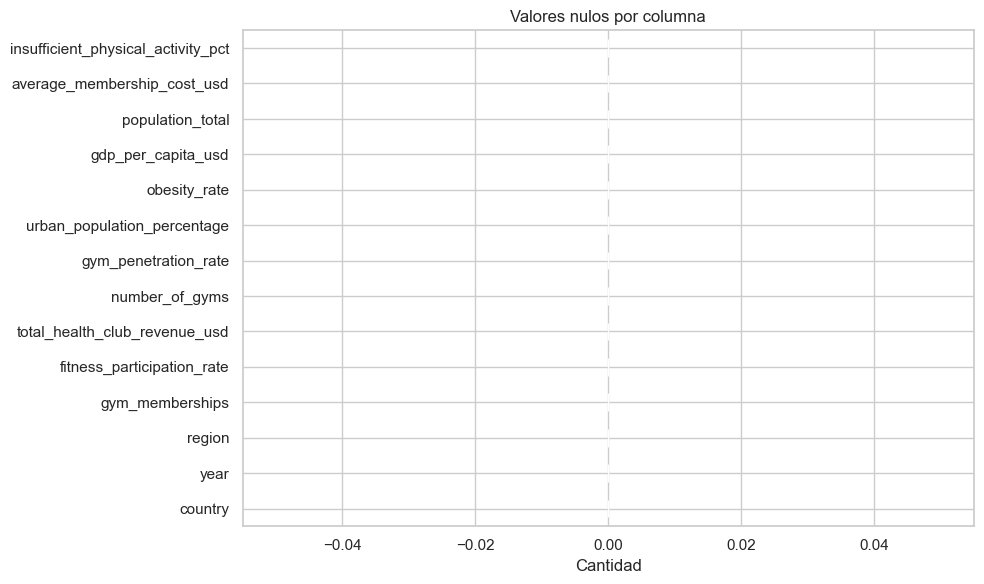

country                               0
year                                  0
region                                0
gym_memberships                       0
fitness_participation_rate            0
total_health_club_revenue_usd         0
number_of_gyms                        0
gym_penetration_rate                  0
urban_population_percentage           0
obesity_rate                          0
gdp_per_capita_usd                    0
population_total                      0
average_membership_cost_usd           0
insufficient_physical_activity_pct    0
dtype: int64

In [2]:
nulls = df.isnull().sum()
nulls.plot(kind="barh", color="indianred", figsize=(10, 6))
plt.title("Valores nulos por columna")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()
nulls

## Distribución de gym_penetration_rate por región (boxplot)

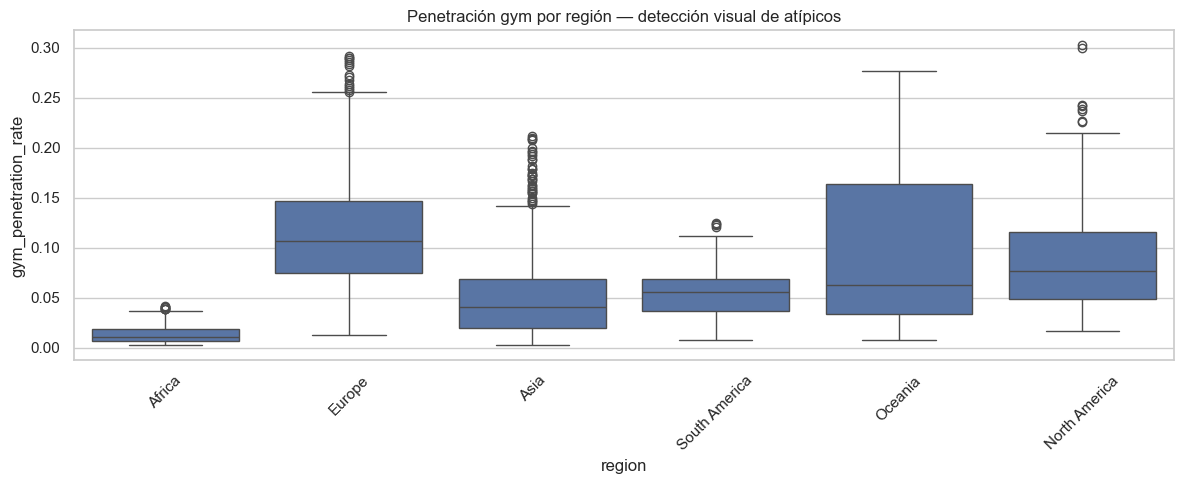

In [3]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="region", y="gym_penetration_rate")
plt.title("Penetración gym por región — detección visual de atípicos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Generar reporte JSON (SCRUM-9)

In [4]:
report = build_quality_report()
out = save_quality_report()
print(f"Guardado: {out}")
print(f"Registros: {report['total_registros']} | Regiones: {report['regiones']}")

# Atípicos IQR — resumen por región (gym_penetration_rate)
for region, cols in report["atipicos_iqr_por_region"].items():
    n = cols.get("gym_penetration_rate", {}).get("count", 0)
    print(f"  {region}: {n} atípicos en gym_penetration_rate")

Guardado: /Users/cpanoh/Documents/cpano-98-local/GitHub/gympulse-ai-backend/reporte_calidad_scrum9.json
Registros: 3564 | Regiones: ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
  Africa: 8 atípicos en gym_penetration_rate
  Asia: 34 atípicos en gym_penetration_rate
  Europe: 15 atípicos en gym_penetration_rate
  North America: 8 atípicos en gym_penetration_rate
  Oceania: 0 atípicos en gym_penetration_rate
  South America: 4 atípicos en gym_penetration_rate
